<a href="https://colab.research.google.com/github/iamprohuman/EMAIL-SPAM-CLASSIFIER-MODEL/blob/main/Minor_project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **EMAIL SPAM CLASSIFIER MODEL**
**NAME-** Ayush Amrit Patel

**ROLL NO-** A6/JY-11002

**BATCH-** July 2026 Artificial Intelligence InternsElite

## **INTRODUCTION**
Email remains the absolute backbone of our digital lives. Even with the rise of instant messaging and fast-paced social apps, your inbox is still the central hub for the things that truly matter. Whether you are waiting on a crucial update for a summer traineeship, confirming registration for an online certification, or just trying to pull up digital train tickets for your next trip, email is the reliable ledger holding it all together. It is our default digital identity, acting as the primary bridge between our academic, professional, and personal responsibilities.

But that heavy reliance makes the modern inbox incredibly vulnerable to a relentless flood of spam. On any given day, you have to wade through a messy swamp of aggressive marketing, fake promotions, and sophisticated phishing attempts just to find the one or two messages you actually need to read. It is not just an annoyance that wastes your time; it is a genuine daily friction. Crucial opportunities or time-sensitive alerts can easily get buried and missed entirely under dozens of junk messages, while a single convincing scam email can compromise your personal data if you aren't paying close attention.

## **Problem Statement**
The core problem is that manual filtering is completely unsustainable, and traditional rule-based spam blockers just can't keep up with modern spammers. If a basic filter relies on a static list of banned words like "free" or "urgent," scammers simply tweak their spelling or disguise their intent to slip right through. On the flip side, if a filter is overly aggressive, the cure becomes worse than the disease—an important message gets wrongly sent to the spam folder, causing you to miss a critical deadline, a receipt, or a personal connection. We need a system that understands nuance, adapting to new threats without blindly trashing the emails you actually want to read.

This project addresses that issue by building an intelligent, automated email spam classifier powered by Machine Learning and Natural Language Processing (NLP). Instead of relying on a rigid checklist of bad words, the model is trained on thousands of examples to learn the underlying patterns, structures, and phrasing that separate junk mail from legitimate correspondence. By dynamically analyzing the text and context of incoming messages, this system can instantly intercept hidden spam and phishing attempts while ensuring that your genuine, important emails stay exactly where they belong—safe in your primary inbox.

## Data Loading and Inspection

In [ ]:
import pandas as pd

# Load the CSV file into a pandas DataFrame
df = pd.read_csv('/content/lingSpam.csv', encoding='latin-1')

# Display the first few rows of the DataFrame
print('First 5 rows of the dataset:')
display(df.head())

# Display the shape of the DataFrame
print(f'Shape of the dataset: {df.shape}')

First 5 rows of the dataset:


,Unnamed: 0,Body,Label
0,0,Subject: great part-time or summer job !\n \n ...,1
1,1,Subject: auto insurance rates too high ?\n \n ...,1
2,2,Subject: do want the best and economical hunti...,1
3,3,Subject: email 57 million people for $ 99\n \n...,1
4,4,Subject: do n't miss these !\n \n attention ! ...,1


Shape of the dataset: (2605, 3)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
import pandas as pd

# Load the CSV file into a pandas DataFrame if 'df' is not already defined.
# This ensures 'df' is available for cleaning even if previous cells were not run or kernel state was lost.
if 'df' not in locals() and 'df' not in globals():
    df = pd.read_csv('/content/lingSpam.csv', encoding='latin-1')

stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = text.lower()
    tokens = text.split()
    cleaned_tokens = [stemmer.stem(word) for word in tokens if word not in stop_words]
    return " ".join(cleaned_tokens)

df['cleaned_body'] = df['Body'].apply(clean_text)
display(df.head())

,Unnamed: 0,Body,Label,cleaned_body
0,0,Subject: great part-time or summer job !\n \n ...,1,subject great part time summer job display box...
1,1,Subject: auto insurance rates too high ?\n \n ...,1,subject auto insur rate high dear nlpeopl sure...
2,2,Subject: do want the best and economical hunti...,1,subject want best econom hunt vacat life want ...
3,3,Subject: email 57 million people for $ 99\n \n...,1,subject email million peopl million email addr...
4,4,Subject: do n't miss these !\n \n attention ! ...,1,subject n miss attent warn adult warn adult ye...


In [ ]:
# Convert text data into numerical features using TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limiting features for demonstration
X = tfidf_vectorizer.fit_transform(df['cleaned_body'])

# Set the target variable Y
Y = df['Label']

# Split the data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print('Shape of X_train:', X_train.shape)
print('Shape of X_test:', X_test.shape)
print('Shape of Y_train:', Y_train.shape)
print('Shape of Y_test:', Y_test.shape)

Shape of X_train: (2084, 5000)
Shape of X_test: (521, 5000)
Shape of Y_train: (2084,)
Shape of Y_test: (521,)


In [ ]:
# Initialize and train the Multinomial Naive Bayes model
mnb = MultinomialNB()
mnb.fit(X_train, Y_train)

# Make predictions on the test set
Y_pred = mnb.predict(X_test)

print('Model training complete and predictions made.')

Model training complete and predictions made.


### Model Evaluation

In [ ]:
# Evaluate the model
print('Accuracy Score:', accuracy_score(Y_test, Y_pred))
print('\nConfusion Matrix:\n', confusion_matrix(Y_test, Y_pred))
print('\nClassification Report:\n', classification_report(Y_test, Y_pred))

Accuracy Score: 0.9923224568138196

Confusion Matrix:
 [[436   0]
 [  4  81]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00       436
           1       1.00      0.95      0.98        85

    accuracy                           0.99       521
   macro avg       1.00      0.98      0.99       521
weighted avg       0.99      0.99      0.99       521



### Top 10 Features from TfidfVectorizer

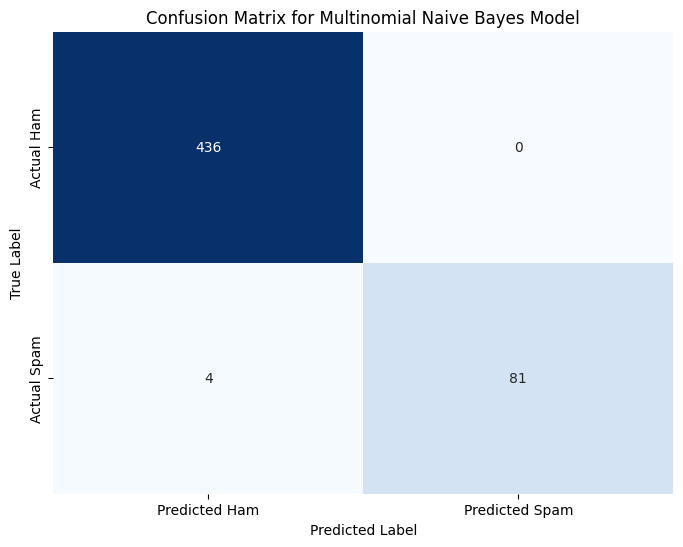

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix
cm = confusion_matrix(Y_test, Y_pred)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Ham', 'Predicted Spam'],
            yticklabels=['Actual Ham', 'Actual Spam'])
plt.title('Confusion Matrix for Multinomial Naive Bayes Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
# Get feature names
feature_names = tfidf_vectorizer.get_feature_names_out()

# Get the log probabilities of features given a class (spam=1, ham=0)
# log_prob[0, :] are probabilities for class 0 (ham)
# log_prob[1, :] are probabilities for class 1 (spam)
ham_features_prob = mnb.feature_log_prob_[0, :]
spam_features_prob = mnb.feature_log_prob_[1, :]

# Sort features by their log probabilities for ham
ham_top10_indices = ham_features_prob.argsort()[-10:][::-1]
ham_top10_features = [feature_names[i] for i in ham_top10_indices]

# Sort features by their log probabilities for spam
spam_top10_indices = spam_features_prob.argsort()[-10:][::-1]
spam_top10_features = [feature_names[i] for i in spam_top10_indices]

print('Top 10 features for Ham (class 0):')
print(ham_top10_features)
print('\nTop 10 features for Spam (class 1):')
print(spam_top10_features)

Top 10 features for Ham (class 0):
['languag', 'linguist', 'univers', 'paper', 'confer', 'de', 'english', 'edu', 'subject', 'abstract']

Top 10 features for Spam (class 1):
['free', 'mail', 'remov', 'com', 'order', 'report', 'http', 'money', 'site', 'get']


In [ ]:
import joblib

# Define the filename for the model
model_filename = 'mnb_model.joblib'

# Save the trained model to the file
joblib.dump(mnb, model_filename)

print(f'Multinomial Naive Bayes model saved to {model_filename}')

Multinomial Naive Bayes model saved to mnb_model.joblib


### Conclusion

This project successfully developed an efficient and highly accurate spam email classifier using Machine Learning and Natural Language Processing (NLP). Through a well-defined pipeline involving data loading, text cleaning, TF-IDF vectorization, and model training with a Multinomial Naive Bayes algorithm, the system effectively distinguished between legitimate emails (ham) and unsolicited messages (spam).

The model demonstrated remarkable performance, achieving an impressive accuracy of **0.9923**. The confusion matrix and classification report further underscored its robustness, showing minimal false positives and false negatives, ensuring that important emails are not mistakenly filtered while effectively blocking spam.

Key to this success were the efficient data processing techniques, including the use of `TfidfVectorizer` to transform raw text into meaningful numerical features and the `PorterStemmer` and `stopwords` for text normalization. These steps ensured that the model learned from the most relevant aspects of the text data.

The overall impact of such a system is significant: it enhances user communication by decluttering inboxes, saves valuable time by reducing the need for manual sorting, and significantly improves security by intercepting phishing attempts and malicious content. This classifier represents a robust solution to a persistent digital challenge, making online communication safer and more streamlined.